### Time Series plots of hydropower generation and capacity under drought 

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import numpy as np

In [3]:
global_hydropower_hybrid_prediction = pd.read_csv("/scratch/shah0012/hybrid_hydropower_model/hybrid_model_results/global_data_prediction_designed_dataset_drought_attributes_included_1982_2022_target_CF.csv", parse_dates = ["date"])

glohydrores_df = pd.read_excel("/home/shah0012/GloHydroRes/Output_data/GloHydroRes_vs2.xlsx", sheet_name = "Data")


# IPCC climate region shape file
IPCC_climate_regions = gpd.read_file("/scratch/shah0012/hybrid_hydropower_model/data/IPCC_climate_regions/IPCC-WGI-reference-regions-v4.shp")
geometry = [Point(xy) for xy in zip(glohydrores_df['plant_lon'], glohydrores_df['plant_lat'])]
glohydrores_gdf = gpd.GeoDataFrame(glohydrores_df, geometry=geometry, crs=IPCC_climate_regions.crs)
glohydrores_gdf = gpd.sjoin(glohydrores_gdf, IPCC_climate_regions, how='left', predicate='within')
global_hydropower_hybrid_prediction["acronym"] = global_hydropower_hybrid_prediction["glohydrores_plant_id"].map(dict(zip(glohydrores_gdf.ID, glohydrores_gdf.Acronym)))
global_hydropower_hybrid_prediction["com_year"] = global_hydropower_hybrid_prediction["glohydrores_plant_id"].map(dict(zip(glohydrores_gdf.ID, glohydrores_gdf.year)))

# Remove the predictions from each hydropower plant before plant commission year
global_hydropower_hybrid_prediction  = global_hydropower_hybrid_prediction[global_hydropower_hybrid_prediction.date.dt.year >= global_hydropower_hybrid_prediction.com_year]
global_hydropower_hybrid_prediction["year"] = global_hydropower_hybrid_prediction.date.dt.year

#### Calculate regional hydropower capacity factor time series

In [11]:

# Calculate the weighted capacity factor based on installed capacity and also simple average capacity factor
regional_monthly_stats  = global_hydropower_hybrid_prediction.groupby(["acronym", "date"]).apply(
        lambda group: pd.Series({
            # Capacity-weighted average CF
            'regional_weighted_CF': (
                group['predicted_CF'] * group['installed_capacity_mw']
            ).sum() / group['installed_capacity_mw'].sum(),
            
            # Simple average CF (for comparison)
            'regional_simple_avg_CF': group['predicted_CF'].mean()

        })).reset_index()

regional_monthly_stats["month"] = regional_monthly_stats.date.dt.month

long_term_mean = regional_monthly_stats.groupby(["acronym", "month"])["regional_weighted_CF"].mean().reset_index()
long_term_mean.rename(columns = {"regional_weighted_CF" : "long_term_weighted_CF"}, inplace = True)
regional_monthly_stats = regional_monthly_stats.merge(long_term_mean, on =["acronym", "month"], how = "left")
regional_monthly_stats["pct_dv"] = ((regional_monthly_stats.regional_weighted_CF - regional_monthly_stats.long_term_weighted_CF)/( regional_monthly_stats.long_term_weighted_CF))*100


#### Regional capacity under drought time series

In [12]:
global_hydropower_hybrid_prediction['is_drought'] = (global_hydropower_hybrid_prediction['drought_20_pooled_3length'] > 0).astype(int)
global_hydropower_hybrid_prediction['drought_capacity'] = global_hydropower_hybrid_prediction['installed_capacity_mw'] * global_hydropower_hybrid_prediction['is_drought']

regional_drought_result = global_hydropower_hybrid_prediction.groupby(['date', 'acronym']).agg({
        'installed_capacity_mw': 'sum',
        'drought_capacity': 'sum'
    }).reset_index()

regional_drought_result["percent_drought_cap"] = (regional_drought_result["drought_capacity"]/regional_drought_result["installed_capacity_mw"])*100


In [13]:
regional_monthly_stats = regional_monthly_stats.merge(regional_drought_result[["date", "acronym", "drought_capacity", "percent_drought_cap"]], on =["acronym", "date"], how = "left")

In [15]:
# Filter data for all 12 selected regions
selected_regions = ["WNA",  "NES", "SES", "NEU", "MED", "EAS", "NEN", "ENA", "NSA", "WCE", "WCA", "SAS"]
selected_regions_full_name = {"WNA": "Western North America (WNA)", 
"NES" : "Northeastern South America (NES)",
"SES" : "Southeastern South America (SES)",
"NEU" : "Northern Europe (NEU)",
"MED" : "Mediterranean (MED)",
"EAS" : "East Asia (EAS)",
"NEN": "Northeastern North America (NEN)", 
"ENA" : "Eastern North America (ENA)",
"NSA" : "Northern South America (NSA)",
"WCE" : "West & Central Europe (WCE)",
"WCA" : "Western Central Asia (WCA)",
"SAS" : "South Asia (SAS)"}
plot_data = regional_monthly_stats[regional_monthly_stats['acronym'].isin(selected_regions)].copy()
# Ensure date column is datetime
plot_data['date'] = pd.to_datetime(plot_data['date'])


#### Main manuscript regions plot

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

def single_region_plot_func(region):

    fig, ax1 = plt.subplots(1, 1, figsize=(8, 4), dpi = 300)

    # Color schemes
    cf_color = '#1f77b4'  # Blue for CF deviation
    drought_color = '#ff7f0e'  # Orange for drought capacity

    region_data = plot_data[plot_data['acronym'] == region].sort_values('date')
    
    # Primary y-axis (CF deviation)
    line1 = ax1.plot(region_data['date'], region_data['pct_dv'], 
                     color=cf_color, linewidth=2, label='CF Deviation (%)')
    ax1.set_ylabel('Deviation from \nlong term mean (%)', color=cf_color, fontsize=14)
    ax1.tick_params(axis='y', labelcolor=cf_color, labelsize=13)
    ax1.axhline(y=0, color=cf_color, linestyle='--', alpha=0.3)

    # Secondary y-axis (Drought capacity %)
    ax2 = ax1.twinx()
    line2 = ax2.plot(region_data['date'], region_data['percent_drought_cap'], 
                     color=drought_color, linewidth=2, alpha=0.7, label='Drought Capacity (%)')
    ax2.set_ylabel('Capacity under \ninfluence of drought (%)', color=drought_color, fontsize=14)
    ax2.tick_params(axis='y', labelcolor=drought_color, labelsize=13)
    
    # Formatting
    region_full_name = selected_regions_full_name.get(region)
    #ax1.set_title(f'{region_full_name}', fontsize=15)
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(DateFormatter('%Y'))
    ax1.xaxis.set_major_locator(mdates.YearLocator(3))  # Every 3 years for less crowding
    ax1.tick_params(axis="x", rotation=45, labelsize=13)

    plt.tight_layout()
    plt.savefig(f"/home/shah0012/Hydropower_hybrid_model/figures/{region}.pdf",  format="pdf", bbox_inches="tight", dpi=600)

    plt.show()

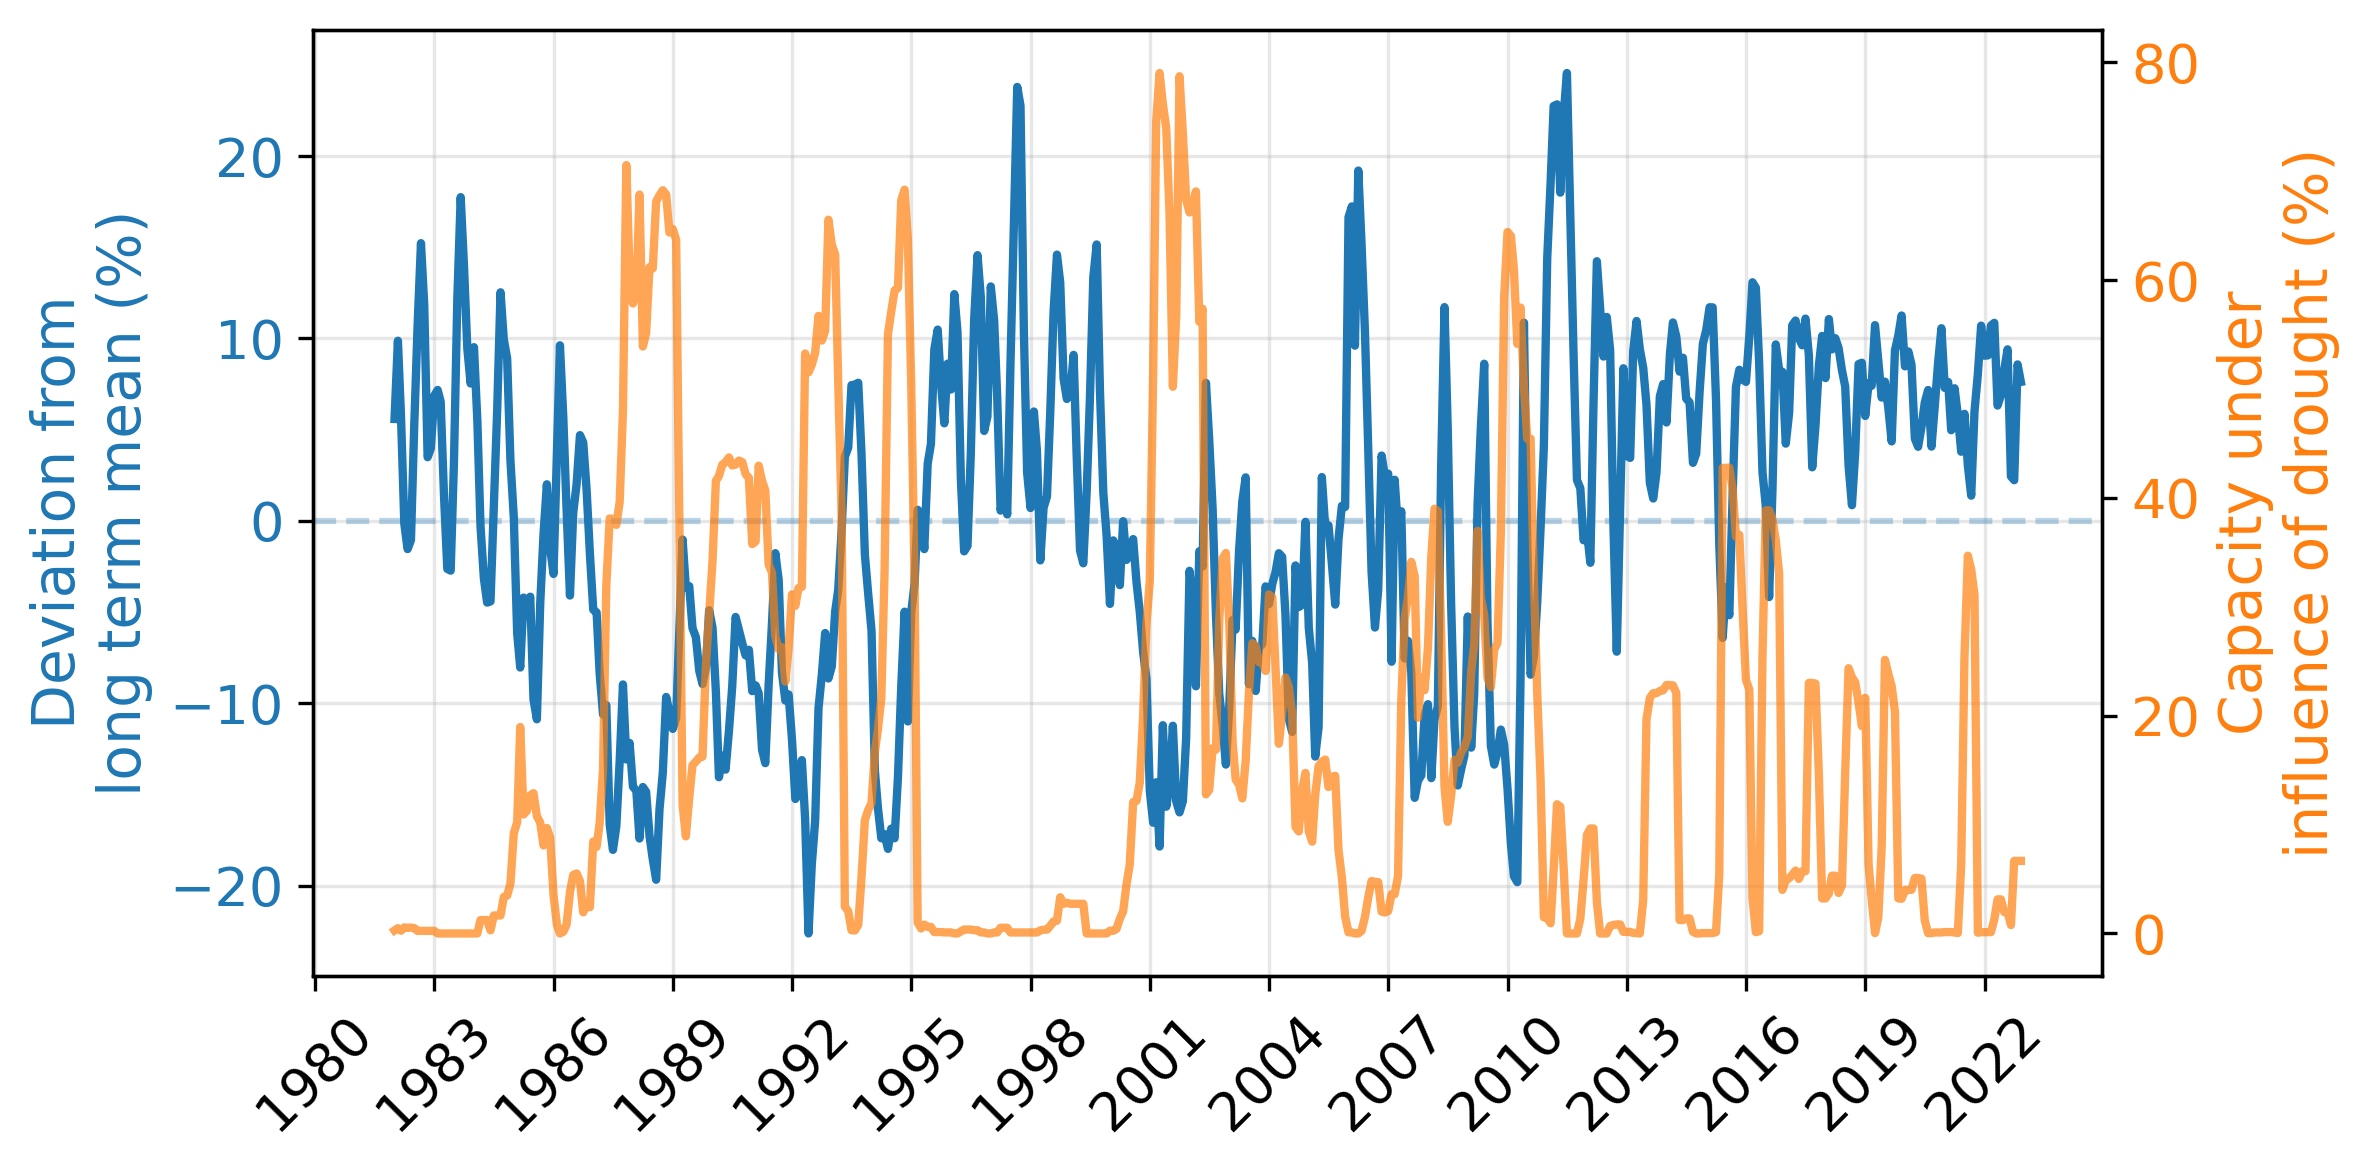

In [ ]:
single_region_plot_func(region  = "WNA")
single_region_plot_func(region  = "NES")
single_region_plot_func(region  = "SES")
single_region_plot_func(region  = "NEU")
single_region_plot_func(region  = "MED")
single_region_plot_func(region  = "EAS")
single_region_plot_func(region  = "NEN")
single_region_plot_func(region  = "ENA")
single_region_plot_func(region  = "NSA")
single_region_plot_func(region  = "WCE")
single_region_plot_func(region  = "WCA")
single_region_plot_func(region  = "SAS")